# Étude des corrélations entre le paramètre de "Danceability" de spotify dans le genre Afrobeats

## Problématique

La "Danceability" d'un morceau est devenue un paramètre répandu dans l'analyse des données des plateformes de streaming musical. C'est un indicateur clé pour prédire si un morceau deviendra un "hit". Avec une valeur variant entre 0 et 1 (équivalant à un pourcentage), le coefficient de "Danceability" est calculé à partir de plusieurs caractéristiques. Parmi celles-ci, on retrouve un tempo (battements par minute ou BPM) relativement élevé (généralement entre 90 et 130 BPM), la stabilité du rythme, la structure musicale, ainsi que l’émotion véhiculée. Cependant, les plateformes de streaming gardent secrètes leurs méthodes de calcul pour conserver un avantage commercial.

Ainsi, la question n'est pas tant de savoir comment la "Danceability" est calculée, mais plutôt de déterminer si ce paramètre peut être corrélé à d’autres caractéristiques, menant à des correspondances intéressantes. Pour faciliter l’analyse et l’interprétation, nous nous focaliserons plus particulièrement sur les morceaux appartenant au genre Afrobeats. Originaire du Nigeria, et différent de l'Afrobeat (qui renvoie plutôt aux œuvres afro punk rock de Fela Kuti et à son influence), l’Afrobeats est un style de musique urbaine influencé par des genres variés comme le Hip Hop, le R&B, le Trap, le Rap ou encore le Reggaeton. Très en vogue en 2024, notamment après le succès d’artistes comme Rema, Burna Boy, Omah Lay, ou Ayra Starr (entre 2020 et 2024), de nombreux morceaux de ce genre présentent un niveau de "Danceability" élevé. Par conséquent, le jeu de données sera composé principalement de morceaux ayant un coefficient élevé de "Danceability".

## Jeu de données

Il s’agit d’un ensemble de données complet et bien documenté contenant de la musique entendue dans tout le Nigeria ainsi que des détails sur chaque morceau. Il n'est pas composé de valeurs abbérentes ou manquantes, il est issu directement de la plateforme Spotify, qui mets à dispositions gratuitement des données et celles-ci sont télécharger par un ETL dans le Data warehouse du site Internet Kaggle. Voici les champs de chaque données : 
###### ID Track
###### Track_url
###### Release_date
###### Duration_mse
###### Explicit
###### Track_popularity
###### Markets
###### Albid
###### Album
###### Album_type
###### Artid
###### Artist
###### Genres
###### Artist_popularity
###### Danceability
###### Instrumentalness
###### Speechiness
###### Valence
###### Loudness
###### Lyrics
###### Added_at

## Questionnement et méthode

En utilisant une méthode hypothético-déductive, la question est de savoir si le coefficient de "Danceability" est corrélé avec le score de popularité des morceaux et celui des artistes. Ainsi, l’indice de corrélation de Pearson sera utilisé pour évaluer ces corrélations, et plus précisément pour mesurer la force et la direction de la relation linéaire entre ces variables, chacune par rapport aux autres, à l'exception des variables "Track Popularity et Artist Popularity", que l’on suppose corrélées. Ces corrélations seront visualisées à travers deux nuages de points. Enfin, une dernière commande sera exécutée pour afficher quelques morceaux de musique significatifs, afin de les écouter et de mieux appréhender les contours et les limites de cette analyse.

## Code

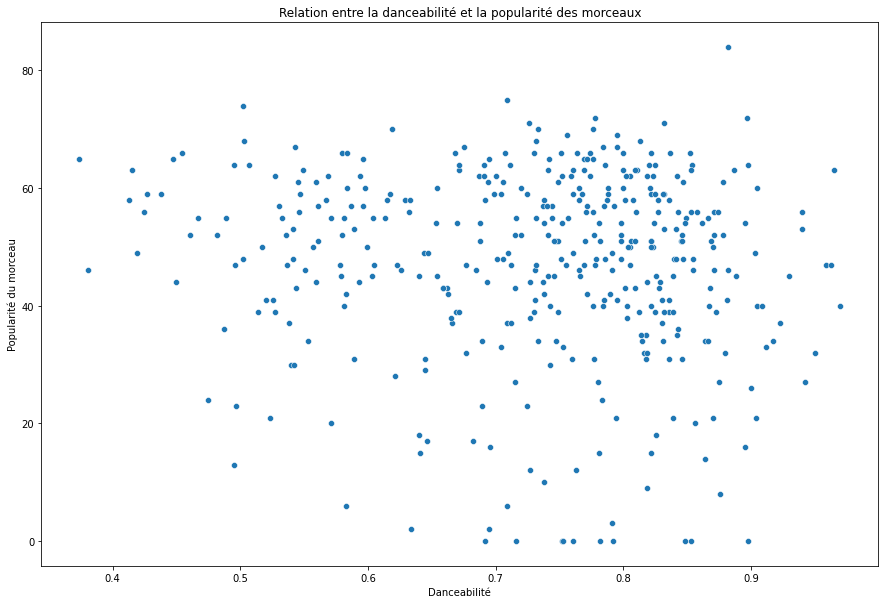

Coefficient de corrélation de Pearson (Danceability vs Track Popularity): -0.08782630151420237
,P-value: 0.07823358172472834


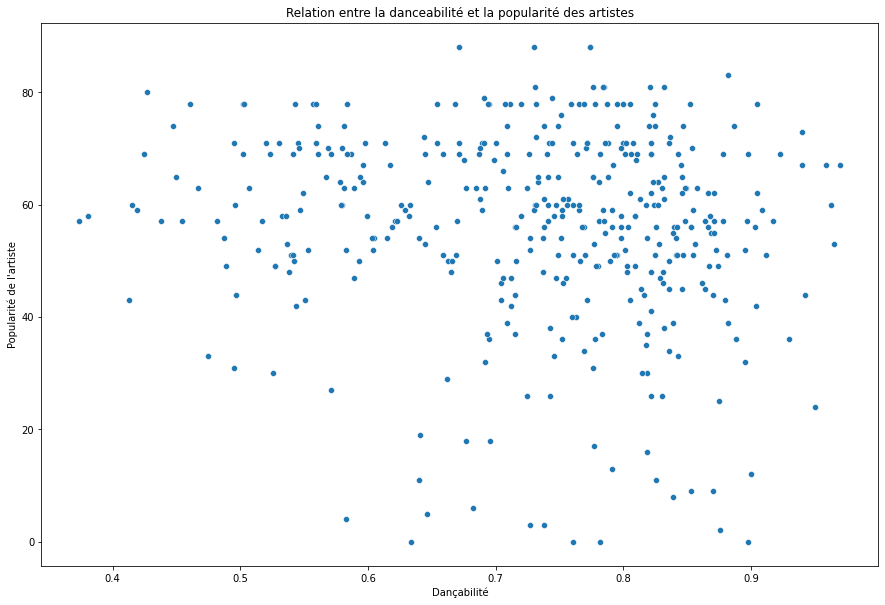

Coefficient de corrélation de Pearson (Danceability vs Artist Popularity): -0.11106156098338145
,P-value: 0.025779235844649015
,
,Morceaux avec forte dançabilité et popularité élevée (track et artiste) :
,- Track: Lomo Lomo | Artist: KiDi | URL: https://open.spotify.com/track/12jJRu9yInIX7oTxoXtM0S
,- Track: Monalisa | Artist: Lojay | URL: https://open.spotify.com/track/1zwZ26A7OA5wTrA3FejCLL
,- Track: Omo Ope (feat. Olamide) | Artist: Asake | URL: https://open.spotify.com/track/7d1aTQlsHMgWmkPywDi7h1
,- Track: Romeo Must Die (RMD) | Artist: Ruger | URL: https://open.spotify.com/track/4EoYs4KY7oHQpJPTuxD7mU
,- Track: yawa | Artist: Fireboy DML | URL: https://open.spotify.com/track/5tM3Fo4qBqDAwWJ9ZY5AtX
,- Track: BAND4BAND (feat. Lil Baby) | Artist: Central Cee | URL: https://open.spotify.com/track/7iabz12vAuVQYyekFIWJxD
,- Track: Ilashe | Artist: Ruger | URL: https://open.spotify.com/track/1kW728xFsRBvunN1yiTsNf
,- Track: My G | Artist: Kizz Daniel | URL: https://open.spotify.com/trac

In [9]:
import pandas as pd # la librairie qui permets de manipuler les données de manière générale et donc de préparer, nettoyer, et d'analyser les données
import matplotlib.pyplot as plt # la librairie pour visualiser des données et faire de graphiques
import seaborn as sns # la librairie pour basée sur matplotlib pour faire des graphiques plus avancés et notamment le nuage de point
from scipy.stats import pearsonr # la librairie permettant de réaliser des calculs statistiques avancés tel que la corrélation de Pearson et le teste d'hypothèse, la P-Value

# Chargement du jeu de données
df = pd.read_csv('2024week40oct.csv')

# Filtre des colonnes track_popularity et danceability
df_filtered = df[['track_popularity', 'danceability', 'artist_popularity', 'track', 'track_url', 'artist']]

# Gestion des valeurs manquantes (supprimer les lignes avec des valeurs manquantes)
df_filtered = df_filtered.dropna()

# Graphique de corrélation entre Danceability et Track Popularity
# Visualisation de la relation avec un nuage de points (scatter plot)
plt.figure(figsize=(15, 10)) # définition de la taille du graphique
sns.scatterplot(data=df_filtered, x='danceability', y='track_popularity') # Définition des axes
plt.title('Relation entre la danceabilité et la popularité des morceaux')  # Titre du graphique
plt.xlabel('Danceabilité')  # Étiquette de l'axe des x
plt.ylabel('Popularité du morceau')  # Étiquette de l'axe des y
plt.show()  # Affichage du graphique

# Calcul de la corrélation de Pearson pour track_popularity
corr_track, p_value_track = pearsonr(df_filtered['danceability'], df_filtered['track_popularity'])

# Affichage du coefficient de corrélation et la p-value
print(f"Coefficient de corrélation de Pearson (Danceability vs Track Popularity): {corr_track}")
print(f"P-value: {p_value_track}")

# Graphique de corrélation entre Danceability et Artist Popularity
# Visualisation de la relation avec un nuage de points (scatter plot)
plt.figure(figsize=(15, 10)) # définition de la taille du graphique
sns.scatterplot(data=df_filtered, x='danceability', y='artist_popularity')
plt.title('Relation entre la danceabilité et la popularité des artistes')  # Titre du graphique
plt.xlabel('Dançabilité')  # Étiquette de l'axe des x
plt.ylabel('Popularité de l\'artiste')  # Étiquette de l'axe des y
plt.show()  # Afficher le graphique

# Calcul de la corrélation de Pearson pour artist_popularity
corr_artist, p_value_artist = pearsonr(df_filtered['danceability'], df_filtered['artist_popularity'])

# Affichage du coefficient de corrélation et la p-value
print(f"Coefficient de corrélation de Pearson (Danceability vs Artist Popularity): {corr_artist}")
print(f"P-value: {p_value_artist}")

# Liste d'exemples de morceaux
# Morceaux avec une forte danceabilité et une forte popularité (track et artiste)
# Filtrer les morceaux qui ont une danceabilité > 0.8 et une popularité élevée (track et artiste > 50)
high_danceability = df_filtered[(df_filtered['danceability'] > 0.8) & 
                                (df_filtered['track_popularity'] > 50) & 
                                (df_filtered['artist_popularity'] > 50)]

print("\nMorceaux avec forte dançabilité et popularité élevée (track et artiste) :")
if not high_danceability.empty:
    # Parcourir les morceaux qui répondent aux critères et afficher leurs informations
    for idx, row in high_danceability.iterrows():
        print(f"- Track: {row['track']} | Artist: {row['artist']} | URL: {row['track_url']}")
else:
    print("Aucun morceau ne correspond à ces critères.")

# Morceaux avec une forte danceabilité mais faible popularité (track ou artiste)
# Filtrer les morceaux avec danceabilité > 0.8 mais popularité faible (track ou artiste < 50)
low_correlation = df_filtered[(df_filtered['danceability'] > 0.8) & 
                              ((df_filtered['track_popularity'] < 50) | 
                               (df_filtered['artist_popularity'] < 50))]

print("\nMorceaux avec forte dançabilité mais popularité faible (track ou artiste) :")
if not low_correlation.empty:
    # Parcourir les morceaux qui répondent aux critères et afficher leurs informations
    for idx, row in low_correlation.iterrows():
        print(f"- Track: {row['track']} | Artist: {row['artist']} | URL: {row['track_url']}")
else:
    print("Aucun morceau ne correspond à ces critères.")
